# Spike-Frequency Adaptation

Many neurons fire rapidly at the onset of a sustained stimulus and then slow down. This **spike-frequency adaptation** is commonly produced by a calcium-activated potassium current (an AHP current): each spike admits calcium, calcium gradually activates the AHP conductance, and the growing outward current lengthens successive inter-spike intervals (ISIs).

In [1]:
import brainstate
import braintools
import brainunit as u
import numpy as np
import matplotlib.pyplot as plt
import braincell

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## A cell with an AHP current

We combine sodium and delayed-rectifier potassium for spiking, a set of L-, N-, T-, and high-threshold calcium currents as the calcium source, and a calcium-activated potassium current (`AHP_De1994`) created on a `MixIons` group of K and Ca.

In [2]:
class AdaptingCell(braincell.SingleCompartment):
    """A thalamic-relay-style cell with Ca-activated K (AHP) current."""
    def __init__(self, size, solver='ind_exp_euler'):
        super().__init__(size, V_initializer=braintools.init.Constant(-65. * u.mV),
                         V_th=20. * u.mV, solver=solver)
        self.na = braincell.ion.SodiumFixed(size, E=50. * u.mV)
        self.na.add(INa=braincell.channel.Na_Ba2002(size, V_sh=-30 * u.mV))
        self.k = braincell.ion.PotassiumFixed(size, E=-90. * u.mV)
        self.k.add(IKL=braincell.channel.K_Leak(size, g_max=0.01 * (u.mS / u.cm ** 2)))
        self.k.add(IDR=braincell.channel.KDR_Ba2002(size, V_sh=-30. * u.mV))
        self.ca = braincell.ion.CalciumDetailed(size, C_rest=5e-5 * u.mM,
                                                tau=10. * u.ms, d=0.5 * u.um)
        self.ca.add(ICaL=braincell.channel.CaL_IS2008(size, g_max=0.5 * (u.mS / u.cm ** 2)))
        self.ca.add(ICaN=braincell.channel.CaN_IS2008(size, g_max=0.5 * (u.mS / u.cm ** 2)))
        self.ca.add(ICaT=braincell.channel.CaT_HM1992(size, g_max=2.1 * (u.mS / u.cm ** 2)))
        self.ca.add(ICaHT=braincell.channel.CaHT_HM1992(size, g_max=3.0 * (u.mS / u.cm ** 2)))
        self.kca = braincell.MixIons(self.k, self.ca)
        self.kca.add(IAHP=braincell.channel.AHP_De1994(size, g_max=0.3 * (u.mS / u.cm ** 2)))
        self.IL = braincell.channel.IL(size, g_max=0.0075 * (u.mS / u.cm ** 2), E=-70 * u.mV)

## Drive with a sustained current

A constant 2 uA/cm^2 injection evokes repetitive firing. We record the spike times to measure how the ISIs evolve.

In [3]:
cell = AdaptingCell(1)
cell.init_state()

I = 2. * u.uA / u.cm ** 2

def step(t):
    with brainstate.environ.context(t=t):
        cell.update(I)
    return cell.V.value, cell.spike.value

with brainstate.environ.context(dt=0.01 * u.ms):
    times = u.math.arange(0. * u.ms, 500. * u.ms, brainstate.environ.get_dt())
    vs, spikes = brainstate.transform.for_loop(step, times)

spike_times = np.asarray(times[u.math.squeeze(spikes) > 0] / u.ms)
isi = np.diff(spike_times)
print('number of spikes:', spike_times.size)
print('first ISIs (ms):', np.round(isi[:6], 2).tolist())

number of spikes: 32
first ISIs (ms): [8.369999885559082, 11.470000267028809, 14.09000015258789, 15.34000015258789, 15.720000267028809, 15.800000190734863]


## Visualize the adaptation

The voltage trace (top) shows firing that slows over time; the ISI sequence (bottom) grows monotonically — the quantitative signature of adaptation.

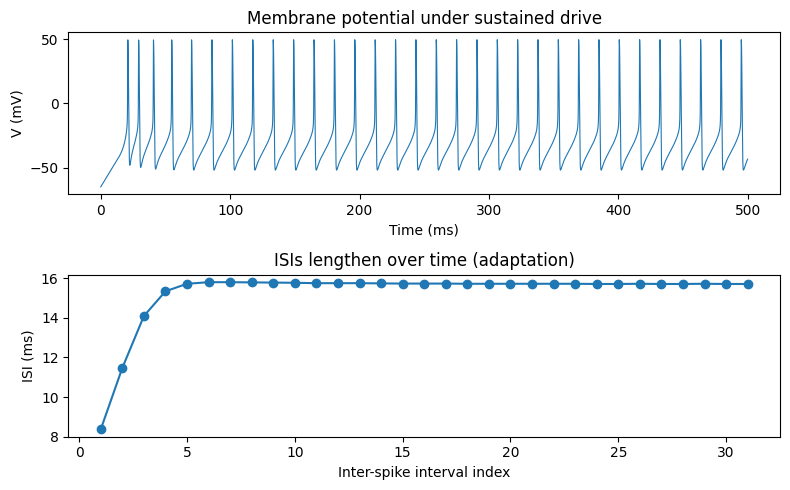

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(8, 5))
axs[0].plot(times / u.ms, u.math.squeeze(vs) / u.mV, linewidth=0.8)
axs[0].set_xlabel('Time (ms)'); axs[0].set_ylabel('V (mV)')
axs[0].set_title('Membrane potential under sustained drive')
axs[1].plot(np.arange(1, isi.size + 1), isi, 'o-')
axs[1].set_xlabel('Inter-spike interval index'); axs[1].set_ylabel('ISI (ms)')
axs[1].set_title('ISIs lengthen over time (adaptation)')
plt.tight_layout(); plt.show()